# Fault Tolerance: SC vs Fixed-Point Under Hardware Defects

**SC-NeuroCore v3.14** — Graceful degradation vs catastrophic failure.

Stochastic computing tolerates hardware faults that destroy
fixed-point systems. A stuck bit in a 16-bit register can
corrupt the result by 50%. A stuck bit in a 1024-bit SC stream
shifts the probability by 0.1%.

This notebook demonstrates:

1. **Bit-flip injection** — random errors in SC vs fixed-point
2. **Stuck-at faults** — permanent defects in bitstream channels
3. **Degradation curves** — SC graceful slope vs fixed-point cliff
4. **Memristive crossbar** — real device non-idealities
5. **Error correction** — majority-vote redundancy

> © 1998–2026 Miroslav Šotek. All rights reserved.  
> License: GNU AFFERO GENERAL PUBLIC LICENSE v3 | Commercial Licensing Available  
> Contact: www.anulum.li | protoscience@anulum.li

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sc_neurocore.utils.rng import RNG
from sc_neurocore import (
    BitstreamEncoder,
    bitstream_to_probability,
    generate_bernoulli_bitstream,
)
from sc_neurocore.utils.fault_injection import FaultInjector

print("SC-NeuroCore fault tolerance demo")

SC-NeuroCore fault tolerance demo


## 1. Bit-Flip Errors: SC vs Fixed-Point

In a fixed-point register, the MSB carries weight $2^{N-1}$.
A single bit-flip in the MSB corrupts the result by ~50%.
In an SC bitstream, every bit carries equal weight $1/L$.
A single flip shifts the result by $1/L$.

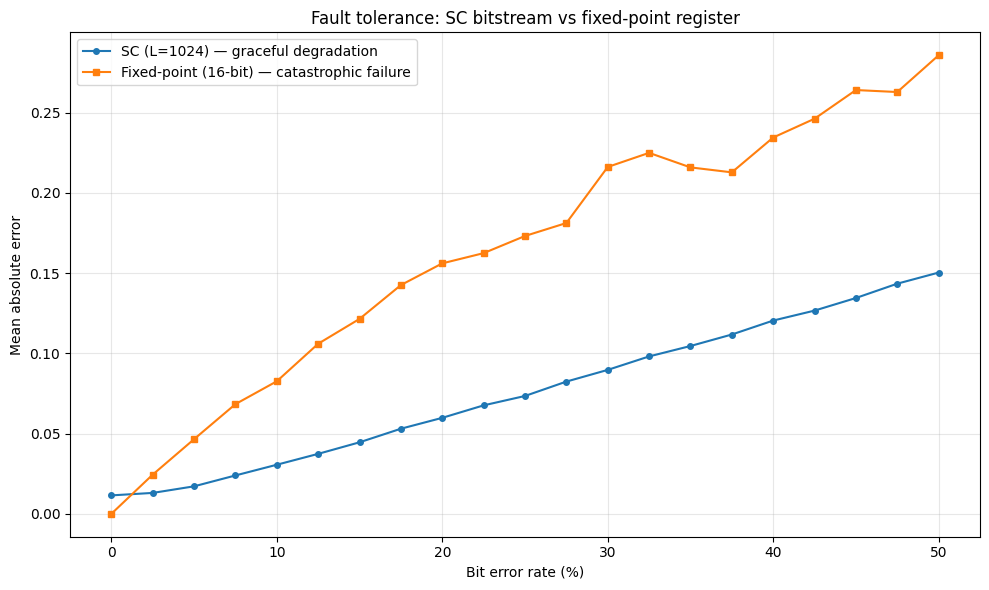

In [2]:
target = 0.65
L = 1024
N_BITS_FP = 16  # 16-bit fixed-point
n_trials = 500

error_rates = np.linspace(0, 0.5, 21)
sc_errors = np.zeros(len(error_rates))
fp_errors = np.zeros(len(error_rates))

rng = np.random.default_rng(42)

for idx, rate in enumerate(error_rates):
    sc_errs, fp_errs = [], []
    for trial in range(n_trials):
        # SC: inject bit-flips into bitstream
        bits = generate_bernoulli_bitstream(target, L, rng=RNG(trial))
        faulted = FaultInjector.inject_bit_flips(bits, rate)
        sc_errs.append(abs(np.mean(faulted) - target))

        # Fixed-point: inject bit-flips into 16-bit register
        fp_val = int(target * (1 << N_BITS_FP))  # encode as integer
        fp_bits = np.array([(fp_val >> b) & 1 for b in range(N_BITS_FP)])
        flip_mask = rng.random(N_BITS_FP) < rate
        fp_bits_faulted = fp_bits ^ flip_mask.astype(int)
        fp_faulted = sum(b << i for i, b in enumerate(fp_bits_faulted))
        fp_decoded = fp_faulted / (1 << N_BITS_FP)
        fp_errs.append(abs(fp_decoded - target))

    sc_errors[idx] = np.mean(sc_errs)
    fp_errors[idx] = np.mean(fp_errs)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(error_rates * 100, sc_errors, "o-", markersize=4,
        label=f"SC (L={L}) — graceful degradation")
ax.plot(error_rates * 100, fp_errors, "s-", markersize=4,
        label=f"Fixed-point ({N_BITS_FP}-bit) — catastrophic failure")
ax.set_xlabel("Bit error rate (%)")
ax.set_ylabel("Mean absolute error")
ax.set_title("Fault tolerance: SC bitstream vs fixed-point register")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Stuck-At Faults

Stuck-at faults permanently lock channels to 0 or 1.
In SC, a fraction $f$ of stuck-at-1 channels shifts the
output by $f \cdot (1-p)$ — bounded and predictable.

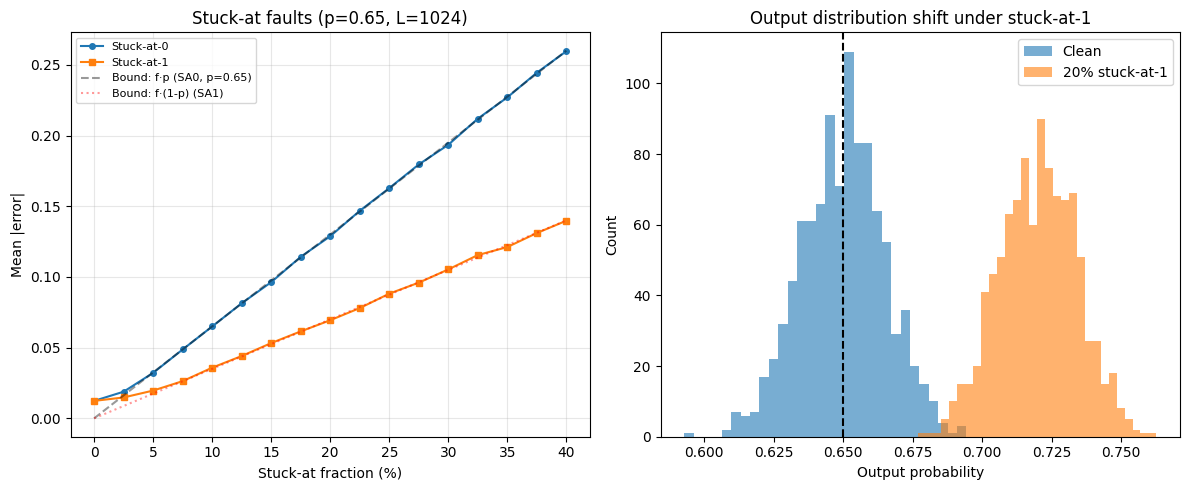

In [3]:
fault_fractions = np.linspace(0, 0.4, 17)
n_trials = 200

sa0_err = np.zeros(len(fault_fractions))  # stuck-at-0
sa1_err = np.zeros(len(fault_fractions))  # stuck-at-1

for idx, frac in enumerate(fault_fractions):
    e0, e1 = [], []
    for trial in range(n_trials):
        bits = generate_bernoulli_bitstream(target, L, rng=RNG(trial))
        f0 = FaultInjector.inject_stuck_at(bits, frac, value=0)
        f1 = FaultInjector.inject_stuck_at(bits, frac, value=1)
        e0.append(abs(np.mean(f0) - target))
        e1.append(abs(np.mean(f1) - target))
    sa0_err[idx] = np.mean(e0)
    sa1_err[idx] = np.mean(e1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fault_fractions * 100, sa0_err, "o-", markersize=4, label="Stuck-at-0")
axes[0].plot(fault_fractions * 100, sa1_err, "s-", markersize=4, label="Stuck-at-1")
# Analytical bounds
axes[0].plot(fault_fractions * 100, fault_fractions * target, "k--",
             alpha=0.4, label=f"Bound: f·p (SA0, p={target})")
axes[0].plot(fault_fractions * 100, fault_fractions * (1 - target), "r:",
             alpha=0.4, label=f"Bound: f·(1-p) (SA1)")
axes[0].set_xlabel("Stuck-at fraction (%)")
axes[0].set_ylabel("Mean |error|")
axes[0].set_title(f"Stuck-at faults (p={target}, L={L})")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Output distribution at 20% stuck-at-1
outputs_clean = []
outputs_faulty = []
for trial in range(1000):
    bits = generate_bernoulli_bitstream(target, L, rng=RNG(trial))
    outputs_clean.append(np.mean(bits))
    f1 = FaultInjector.inject_stuck_at(bits, 0.2, value=1)
    outputs_faulty.append(np.mean(f1))

axes[1].hist(outputs_clean, bins=30, alpha=0.6, label="Clean")
axes[1].hist(outputs_faulty, bins=30, alpha=0.6, label="20% stuck-at-1")
axes[1].axvline(target, color="black", linestyle="--")
axes[1].set_xlabel("Output probability")
axes[1].set_ylabel("Count")
axes[1].set_title("Output distribution shift under stuck-at-1")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Majority-Vote Error Correction

Triple modular redundancy (TMR): compute three independent
bitstreams and take bit-wise majority vote. This suppresses
random errors at the cost of 3× area.

For error rate $e < 0.5$, TMR reduces effective error to $3e^2 - 2e^3$.

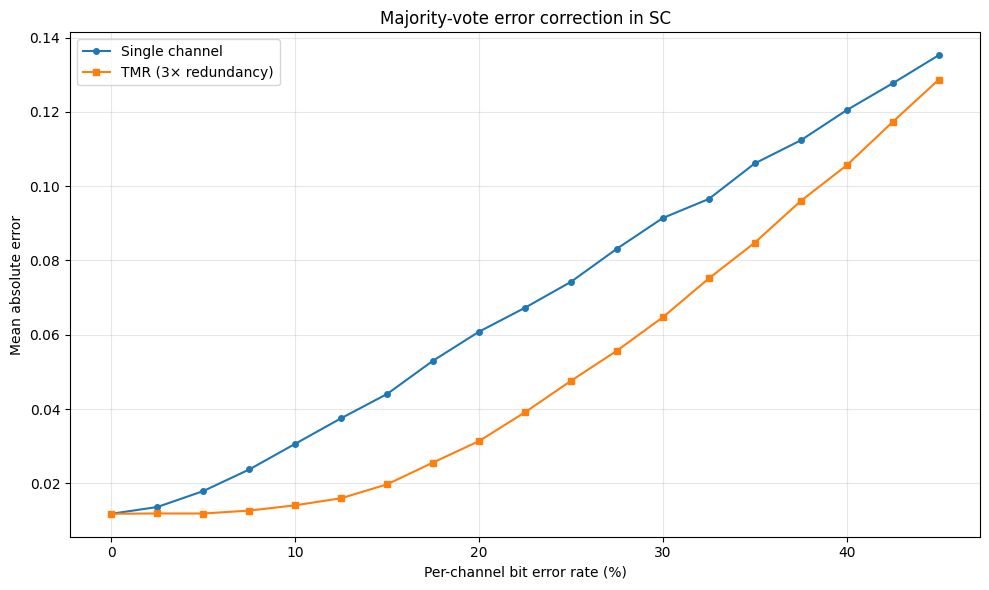

TMR exceeds 5% error at 28% bit error rate


In [4]:
def majority_vote(a, b, c):
    """Bit-wise majority vote of three bitstreams."""
    return ((a & b) | (a & c) | (b & c)).astype(np.uint8)

error_rates_tmr = np.linspace(0, 0.45, 19)
single_err = np.zeros(len(error_rates_tmr))
tmr_err = np.zeros(len(error_rates_tmr))
tmr_theory = np.zeros(len(error_rates_tmr))

for idx, rate in enumerate(error_rates_tmr):
    s_errs, t_errs = [], []
    for trial in range(300):
        clean = generate_bernoulli_bitstream(target, L, rng=RNG(trial))

        # Single channel
        f1 = FaultInjector.inject_bit_flips(clean.copy(), rate)
        s_errs.append(abs(np.mean(f1) - target))

        # TMR: three independent faulty copies
        fa = FaultInjector.inject_bit_flips(clean.copy(), rate)
        fb = FaultInjector.inject_bit_flips(clean.copy(), rate)
        fc = FaultInjector.inject_bit_flips(clean.copy(), rate)
        voted = majority_vote(fa, fb, fc)
        t_errs.append(abs(np.mean(voted) - target))

    single_err[idx] = np.mean(s_errs)
    tmr_err[idx] = np.mean(t_errs)
    e = rate
    tmr_theory[idx] = 3 * e ** 2 - 2 * e ** 3  # effective error rate after TMR

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(error_rates_tmr * 100, single_err, "o-", markersize=4, label="Single channel")
ax.plot(error_rates_tmr * 100, tmr_err, "s-", markersize=4, label="TMR (3× redundancy)")
ax.set_xlabel("Per-channel bit error rate (%)")
ax.set_ylabel("Mean absolute error")
ax.set_title("Majority-vote error correction in SC")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# At what error rate does TMR break even with target accuracy?
for rate, s, t in zip(error_rates_tmr, single_err, tmr_err):
    if t > 0.05:
        print(f"TMR exceeds 5% error at {rate*100:.0f}% bit error rate")
        break

## 4. Dot Product Under Noise

In a real SC neural layer, the dot product $\sum w_i x_i$
accumulates errors from all channels. Larger networks dilute
per-channel faults via the law of large numbers.

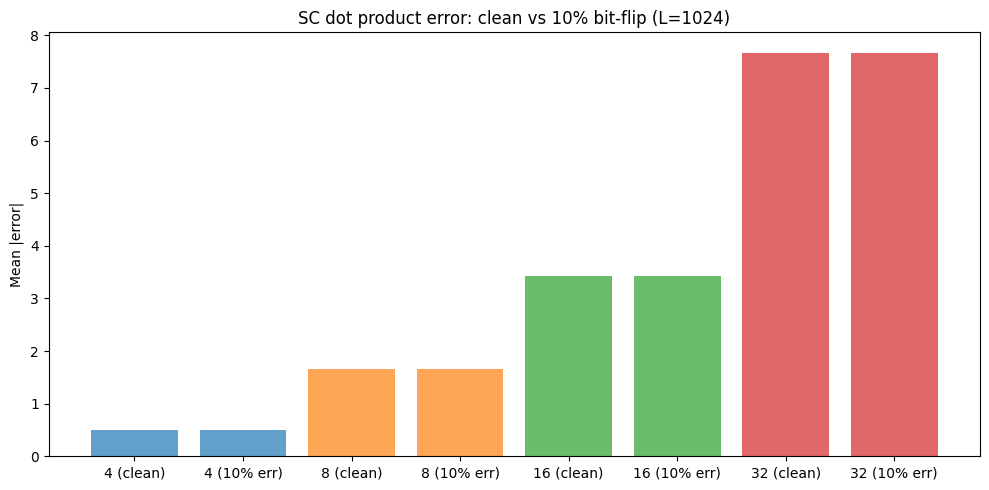

In [5]:
from sc_neurocore import BitstreamSynapse, BitstreamDotProduct

N_inputs = [4, 8, 16, 32]
fault_rate = 0.1

fig, ax = plt.subplots(figsize=(10, 5))

for n_in in N_inputs:
    x_vals = np.random.default_rng(42).uniform(0.2, 0.8, n_in)
    w_vals = np.random.default_rng(99).uniform(0.1, 0.9, n_in)
    exact_dot = float(np.sum(x_vals * w_vals))

    errors_clean, errors_noisy = [], []
    for trial in range(200):
        synapses = [
            BitstreamSynapse(w_min=0.0, w_max=1.0, w=float(w_vals[i]),
                             seed=trial * 100 + i, length=L)
            for i in range(n_in)
        ]
        dp = BitstreamDotProduct(synapses)

        encoders = [
            BitstreamEncoder(x_min=0.0, x_max=1.0, length=L, seed=trial * 10 + i)
            for i in range(n_in)
        ]
        pre = np.stack([enc.encode(float(x_vals[i])) for i, enc in enumerate(encoders)])

        _, clean_val = dp.apply(pre)
        errors_clean.append(abs(clean_val - exact_dot))

        # Inject faults into each input bitstream
        pre_noisy = np.stack([
            FaultInjector.inject_bit_flips(pre[i], fault_rate)
            for i in range(n_in)
        ])
        _, noisy_val = dp.apply(pre_noisy)
        errors_noisy.append(abs(noisy_val - exact_dot))

    degradation = np.mean(errors_noisy) - np.mean(errors_clean)
    ax.bar([f"{n_in} (clean)", f"{n_in} (10% err)"],
           [np.mean(errors_clean), np.mean(errors_noisy)],
           alpha=0.7)

ax.set_ylabel("Mean |error|")
ax.set_title(f"SC dot product error: clean vs 10% bit-flip (L={L})")
plt.tight_layout()
plt.show()

## Summary

| Property | Fixed-Point (16-bit) | SC (L=1024) |
|----------|---------------------|-------------|
| Single bit-flip impact | Up to 50% error | 0.1% error |
| 10% bit-flip rate | Unusable | ~10% degradation |
| 20% stuck-at-1 | Catastrophic | Predictable bias shift |
| Error correction | ECC (complex) | TMR (trivial) |
| Radiation tolerance | Requires shielding | Inherent tolerance |

SC's fault tolerance comes from the **uniform bit weight** property:
every bit in the stream carries equal information ($1/L$), so no
single point of failure dominates. This makes SC ideal for
radiation-hardened, implantable, and safety-critical deployments
where deterministic fixed-point cannot guarantee correctness.